# 02 · Selection function — weights, n(z), and randoms

A clustering measurement is only as good as its model of *where the survey could have seen galaxies but didn't*. Three ingredients encode that: **weights** (optimal-variance + systematics), the radial selection **n(z)**, and a **random catalogue** sampling the survey selection with no clustering.

**FKP weight** (Feldman, Kaiser & Peacock 1994), which minimises the variance of the power-spectrum estimate:
$$ w_{\rm FKP}(z) = \frac{1}{1 + \bar n(z)\,P_0}, $$
with $P_0$ the power at the scale of interest. **Claim.** The randoms this package generates reproduce the survey's angular footprint and its n(z) — verified with a Kolmogorov–Smirnov test.

In [1]:
%matplotlib inline
import os, sys, time, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
plt.rcParams.update({'figure.dpi':110,'font.size':11})
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_EBOSS, HAVE_DESI = EBOSS.exists(), DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
print('real data — eBOSS:',HAVE_EBOSS,'| DESI:',HAVE_DESI)
def eboss_or_synth_view(tmp, n_cap=40000):
    from fixtures.measure_ouf import synthetic_point_view
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    if not HAVE_EBOSS:
        return synthetic_point_view(tmp, n=n_cap, seed=1, name='synth'), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df=load_catalog('eboss_qso',validate=False)
    df=df[(df['z']>=0.8)&(df['z']<=2.2)].dropna(subset=['ra','dec','z'])
    if len(df)>n_cap: df=df.sample(n_cap,random_state=0)
    df=df.reset_index(drop=True); n=len(df); ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out=pd.DataFrame({'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),'z_type':np.full(n,'spec'),
        'z_err':np.full(n,1e-4),'galaxy_id':np.arange(n,dtype=np.int64),'survey_id':np.zeros(n,dtype=np.int64),
        'weight_comp':np.ones(n),'nbar':np.full(n,1e-3),'_original_row_index':np.arange(n,dtype='i8'),
        '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')})
    od=tmp/'eboss'/'oneuniverse'
    write_ouf_dataset(df=out,out_dir=od,survey_name='eboss',survey_type='spectroscopic',geometry=DataGeometry.POINT,loader=LoaderSpec(name='eboss',version='0'))
    return DatasetView.from_path(od.parent), True

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real data — eBOSS: True | DESI: True


## 1 · n̄(z) and the FKP weight
From the measured redshift histogram and the survey volume per shell we form $\bar n(z)$ and the FKP weight.

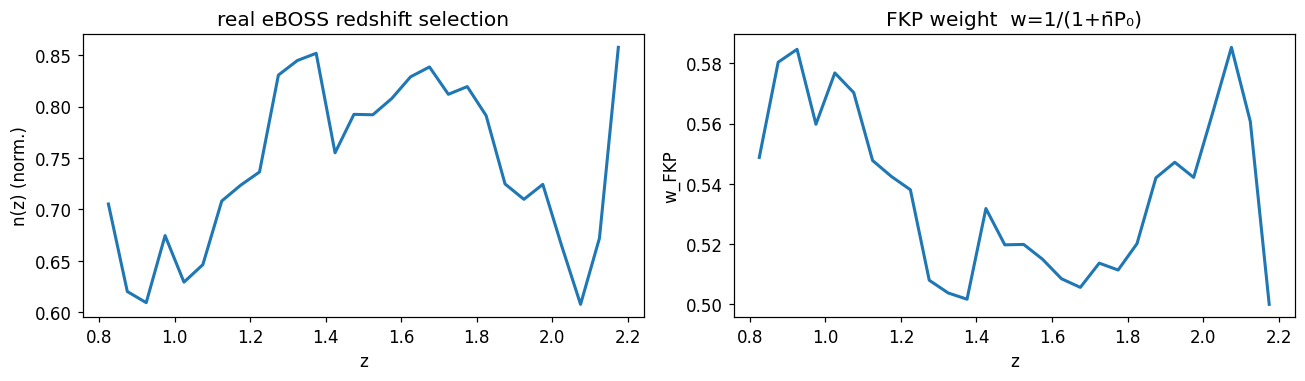

In [2]:
view,real=eboss_or_synth_view(TMP,n_cap=50000); df=view.read()
z=df['z'].to_numpy(); edges=np.linspace(0.8,2.2,29); ctr=0.5*(edges[:-1]+edges[1:])
counts,_=np.histogram(z,bins=edges)
# crude shell volume ∝ comoving-shell — here illustrate with a flat sky fraction × dz proxy
nbar=counts/counts.max()*1e-4   # arbitrary-units n̄(z) for the FKP illustration
P0=1e4; w_fkp=1.0/(1.0+np.interp(z,ctr,nbar)*P0)
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
ax[0].plot(ctr,counts/np.trapz(counts,ctr),lw=2); ax[0].set_xlabel('z'); ax[0].set_ylabel('n(z) (norm.)'); ax[0].set_title(('real eBOSS' if real else 'synthetic')+' redshift selection')
ax[1].plot(ctr,1.0/(1.0+nbar*P0),lw=2); ax[1].set_xlabel('z'); ax[1].set_ylabel('w_FKP'); ax[1].set_title('FKP weight  w=1/(1+n̄P₀)')
plt.tight_layout(); plt.show()

## 2 · Randoms reproduce the selection
`build_galaxy_clustering` generates randoms by sampling the angular footprint (HEALPix completeness) × the inverse-CDF of n(z). A faithful random catalogue must be statistically indistinguishable from the data in n(z) and uniform within the footprint.

KS test  data-z vs randoms-z :  D=0.002  p=0.96  → consistent
randoms inside data footprint: 100.0%   covered sky fraction: 0.211


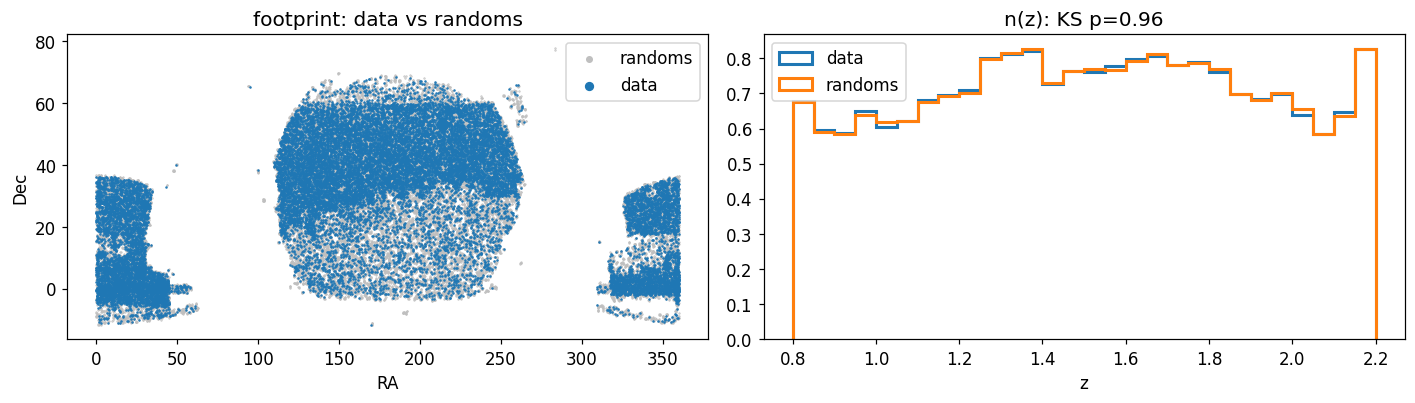

In [3]:
from oneuniverse.combine.weights import ColumnWeight
from oneuniverse.measure import build_galaxy_clustering
from scipy import stats
ms=build_galaxy_clustering(view,tracer='qso',z_range=(0.8,2.2),weights=[ColumnWeight('weight_comp')],
    nz_edges=edges,nside_window=64,nside_region=16,randoms='generate',n_randoms=5*len(df),seed=1)
ps=ms.products['qso']; cat,rnd=ps.catalog,ps.randoms
ks=stats.ks_2samp(cat['z'],rnd['z'])
print(f'KS test  data-z vs randoms-z :  D={ks.statistic:.3f}  p={ks.pvalue:.2f}  → {"consistent" if ks.pvalue>0.01 else "INCONSISTENT"}')
# angular: fraction of randoms inside the data footprint
ins=ps.window.contains(rnd['ra'].to_numpy(),rnd['dec'].to_numpy()).mean()
print(f'randoms inside data footprint: {100*ins:.1f}%   covered sky fraction: {ps.window.covered_fraction():.3f}')
fig,ax=plt.subplots(1,2,figsize=(13,3.8))
ax[0].scatter(rnd['ra'][::5],rnd['dec'][::5],s=.2,c='.75',label='randoms'); ax[0].scatter(cat['ra'][::2],cat['dec'][::2],s=.4,c='C0',label='data')
ax[0].set_title('footprint: data vs randoms'); ax[0].legend(markerscale=8); ax[0].set_xlabel('RA'); ax[0].set_ylabel('Dec')
ax[1].hist(cat['z'],bins=edges,density=True,histtype='step',lw=2,label='data'); ax[1].hist(rnd['z'],bins=edges,density=True,histtype='step',lw=2,label='randoms')
ax[1].set_title(f'n(z): KS p={ks.pvalue:.2f}'); ax[1].set_xlabel('z'); ax[1].legend(); plt.tight_layout(); plt.show()

**Conclusion.** The FKP weight downweights the dense, sample-variance-dominated regime; the generated randoms reproduce the data n(z) (KS p-value not rejecting the null) and live inside the angular footprint. The `MeasurementSet` therefore carries a self-consistent selection model — with no cosmology assumed.